In [1]:
import sys
sys.path.append('../')
import numpy as np
from ept_mark import mark
import json,os,sys
import matplotlib.pyplot as plt
from classy import Class

In [2]:
params = {'output': 'mPk',
          'P_k_max_h/Mpc': 3.,
          'non linear':'halofit', 
          'z_pk': '0.0,1087',
          'A_s': 2.0830e-9,
          'n_s': 0.9649,
          'alpha_s': 0.,
          'h': 0.6736,
          'N_ur': 2.0328,
          'N_ncdm': 1,
          'tau_reio': 0.0544,
          'omega_ncdm': 0.00064420,
          'omega_b': 0.02237,
          'omega_cdm': 0.1200,
          'Omega_k': 0.}
cosmo = Class() 
cosmo.set(params) 
cosmo.compute() 

In [3]:
kmin = 5e-4
kmax = 1.
Nk = 500
h = cosmo.pars['h']
z= 1.1
k = np.logspace(np.log10(kmin),np.log10(kmax),Nk) # [h/Mpc]
plin = np.array([cosmo.pk_cb_lin(kk*h,z)*h**3. for kk in k]) 
f = cosmo.scale_independent_growth_factor_f(z)

In [4]:
Cn = [1.,-1.,0,0]
Rcut = 30
testdir = './'
plin = np.array([cosmo.pk_cb_lin(kk*h,z)*h**3. for kk in k]) 
f = cosmo.scale_independent_growth_factor_f(z)
temp_mark = mark(k,plin,nk=200,Cn=Cn,R=Rcut,name='example',N=2000,basedir=testdir)

In [5]:
# compute contributions for each higher point term in bias and mark basis
temp_mark.compute_tables(f,write=False)
# the lengthy part of the computation can be saved with write=True

no integral13... computing
no integral13_unity... computing
no integral22_W... computing


In [6]:
# define nuisance parameters (see Ebina+24 for details https://arxiv.org/abs/2409.17133): 
# b1, b2, bs, b3, alpha0, alpha2, alpha4, alpha6, sn, sn2, sn4 (one-loop power spectrum nuisance parameters)
# bshot, b0 (tree-level bispectrum nuisance parameters, Appendix A)
# nm0, nm2 (stochastic contributions, Eqn. 2.26)
# db, df (higher loop-order large-scale corrections, Eqn. 3.6) 
pars = [1.2, -1.5, 0, 0,
       -3,3,0,0,
       3000,0,0,
       1,1,0,0,0,0]

# use the computed tables to compute power for specific mark and nuisance paramters 

# if unspecified, temp_mark will call its registered mark (Cn)
Mk1 = temp_mark.compute_power(pars,f)
# you can also specify
Mk2 = temp_mark.compute_power(pars,f,Cn=[1,0,0,0], Cn2=[1,-1,0,0])

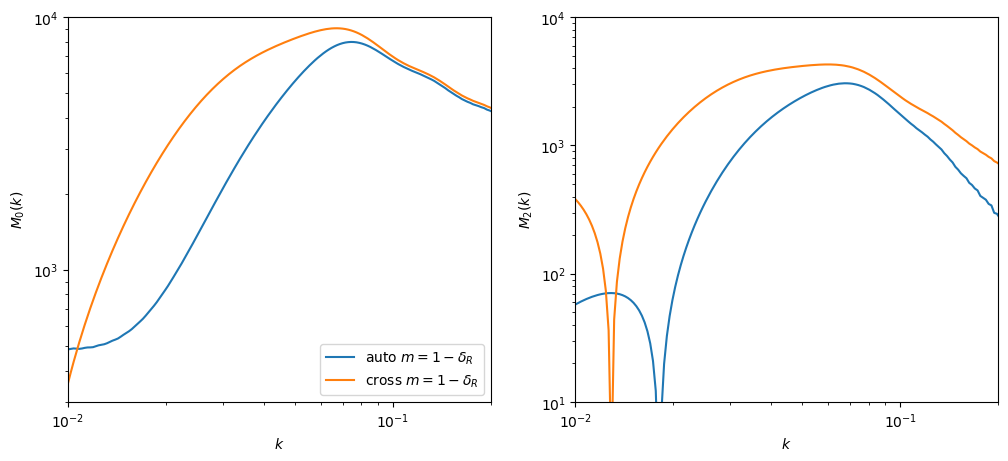

In [7]:
fig,axs = plt.subplots(1,2,figsize=(12,5))
ax = axs[0]
ax.plot(temp_mark.kv,Mk1[0],label=r'auto $m=1-\delta_R$')
ax.plot(temp_mark.kv,Mk2[0],label=r'cross $m=1-\delta_R$')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(.01,.2); ax.set_ylim(3e2,1e4)
ax.set_ylabel(r'$M_0(k)$')
ax.set_xlabel(r'$k$')
ax.legend(loc='lower right')

ax = axs[1]
ax.plot(temp_mark.kv,np.abs(Mk1[1]))
ax.plot(temp_mark.kv,np.abs(Mk2[1]))
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(.01,.2); ax.set_ylim(.1e2,1e4)
ax.set_ylabel(r'$M_2(k)$')
ax.set_xlabel(r'$k$')

fig.show()